# Notebook 2 — APTOS 2019 Classification Preprocessing
**Paper:** *A Comprehensive Deep-Learning Framework Integrating Lesion Segmentation and Stage Classification for Enhanced Diabetic Retinopathy Diagnosis*
**Authors:** Incir & Bozkurt | Int J Imaging Syst Tech, 2026

---

## What this notebook does
Preprocesses the APTOS 2019 dataset (3662 fundus images, 5-class DR grading) into
class-balanced, training-ready image folders for the ViT-CBAM classifier (Stage 2).

## Pipeline
1. Mount Google Drive
2. Read `archive.zip` without extracting
3. Load CSV labels from inside the zip
4. For each image: remove optic disc -> resize 224x224 -> augment (train only)
5. Save PNGs to class-labelled subfolders on Drive
6. Verify counts + plot before/after class distribution

## Expected I/O
| | Path |
|---|---|
| **Input** | `MyDrive/DR_PROJECT/datasets/archive.zip` |
| **Output** | `MyDrive/DR_PROJECT/preprocessed/APTOS_classification/{train,val}/{0-4}/*.png` |

## Class-balanced augmentation
APTOS 2019 is heavily imbalanced. Each class is augmented to ~3500 images for balanced training.

| DR Grade | Name | ~Count | x Factor | After |
|---|---|---|---|---|
| 0 | No DR | 1805 | 1 | 1805 |
| 1 | Mild | 370 | 9 | 3330 |
| 2 | Moderate | 999 | 3 | 2997 |
| 3 | Severe | 193 | 18 | 3474 |
| 4 | Proliferative | 295 | 12 | 3540 |

> **Note:** The lesion overlay step (adding U-Net segmentation masks onto APTOS images) is in
> Notebook 4, after the U-Net models are trained in Notebook 3.

## Cell 1 — Mount Drive & Install Dependencies

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q tqdm pandas

import os, random, zipfile
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

print('Libraries loaded.')

Mounted at /content/drive
Libraries loaded.


## Cell 2 — Configuration
Update `BASE_PATH` if your Drive folder structure differs. All numerical values are from the paper.

In [2]:
BASE_PATH   = '/content/drive/MyDrive/DR_PROJECT/datasets'
OUTPUT_BASE = '/content/drive/MyDrive/DR_PROJECT/preprocessed'
APTOS_ZIP   = os.path.join(BASE_PATH, 'archive.zip')
APTOS_OUT   = os.path.join(OUTPUT_BASE, 'APTOS_classification')

os.makedirs(APTOS_OUT, exist_ok=True)

FINAL_SIZE  = 224
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

CLASS_NAMES = {0: 'No_DR', 1: 'Mild', 2: 'Moderate', 3: 'Severe', 4: 'Proliferative'}

# Per-class augmentation multipliers to balance training set to ~3500 images/class
# Based on APTOS 2019 approximate distribution: [1805, 370, 999, 193, 295]
AUGMENT_FACTORS = {0: 1, 1: 9, 2: 3, 3: 18, 4: 12}

print(f'APTOS zip  : {APTOS_ZIP}')
print(f'Output dir : {APTOS_OUT}')
print(f'Final size : {FINAL_SIZE}x{FINAL_SIZE}')
print('\nAugmentation factors per class:')
for cls, factor in AUGMENT_FACTORS.items():
    print(f'  Class {cls} ({CLASS_NAMES[cls]:<14}): x{factor}')

APTOS zip  : /content/drive/MyDrive/DR_PROJECT/datasets/archive.zip
Output dir : /content/drive/MyDrive/DR_PROJECT/preprocessed/APTOS_classification
Final size : 224x224

Augmentation factors per class:
  Class 0 (No_DR         ): x1
  Class 1 (Mild          ): x9
  Class 2 (Moderate      ): x3
  Class 3 (Severe        ): x18
  Class 4 (Proliferative ): x12


## Cell 3 — Validate APTOS Zip & Load CSV Labels

Reads zip table of contents (instant, no extraction) then loads both CSV label files
directly from within the zip using pandas. Auto-detects the image path prefix to handle
archives where images are nested: `train_images/train_images/*.png`.

In [3]:
print('Reading APTOS zip (no extraction)...')
with zipfile.ZipFile(APTOS_ZIP, 'r') as zf:
    APTOS_NAMES = set(zf.namelist())

    with zf.open('train_1.csv') as f:
        train_df = pd.read_csv(f)
    with zf.open('valid.csv') as f:
        val_df = pd.read_csv(f)

    test_df, HAS_TEST_LABELS = None, False
    if 'test.csv' in APTOS_NAMES:
        with zf.open('test.csv') as f:
            test_df = pd.read_csv(f)
        HAS_TEST_LABELS = 'diagnosis' in test_df.columns

print(f'Zip entries : {len(APTOS_NAMES)}')
print(f'Train rows  : {len(train_df)}')
print(f'Val rows    : {len(val_df)}')
if test_df is not None:
    print(f'Test rows   : {len(test_df)}  (labels: {HAS_TEST_LABELS})')

# Auto-detect full internal folder path by matching a sample id_code
# APTOS archives often nest: train_images/train_images/xxx.png
def find_prefix(names, sample_id):
    for n in names:
        if sample_id in n and n.endswith('.png'):
            return n[:n.rfind('/') + 1]
    return ''

TRAIN_PREFIX = find_prefix(APTOS_NAMES, train_df['id_code'].iloc[0])
VAL_PREFIX   = find_prefix(APTOS_NAMES, val_df['id_code'].iloc[0])
TEST_PREFIX  = find_prefix(APTOS_NAMES, test_df['id_code'].iloc[0]) if test_df is not None else ''

print(f'\nTrain prefix : "{TRAIN_PREFIX}"')
print(f'Val   prefix : "{VAL_PREFIX}"')

print('\nClass distribution (train):')
print(f'  {"Cls":<4} {"Name":<15} {"Count":>6}  {"x":>3}  {"After aug":>9}')
print(f'  {"-"*42}')
for cls, name in CLASS_NAMES.items():
    count = int((train_df['diagnosis'] == cls).sum())
    after = count * AUGMENT_FACTORS[cls]
    print(f'  {cls:<4} {name:<15} {count:>6}  {AUGMENT_FACTORS[cls]:>3}  {after:>9}')

Reading APTOS zip (no extraction)...
Zip entries : 3665
Train rows  : 2930
Val rows    : 366
Test rows   : 366  (labels: True)

Train prefix : "train_images/train_images/"
Val   prefix : "val_images/val_images/"

Class distribution (train):
  Cls  Name             Count    x  After aug
  ------------------------------------------
  0    No_DR             1434    1       1434
  1    Mild               300    9       2700
  2    Moderate           808    3       2424
  3    Severe             154   18       2772
  4    Proliferative      234   12       2808


## Cell 4 — OD Removal & Augmentation Functions

Unlike IDRiD, APTOS has no ground-truth OD masks. Detection uses the green channel brightness
peak — the OD is the brightest compact region in the retinal green channel.

| Function | Purpose |
|---|---|
| `load_from_zip` | Decode image bytes from open zip handle |
| `detect_od_mask` | Locate OD via green-channel max; return circular binary mask |
| `remove_od_aptos` | Inpaint the detected OD region (TELEA) |
| `augment_single` | Apply one of 4 augmentation strategies deterministically by index |

In [4]:
def load_from_zip(zf, zip_path, grayscale=False):
    '''Decode an image directly from an open ZipFile without extracting to disk.'''
    if zip_path not in APTOS_NAMES:
        return None
    with zf.open(zip_path) as f:
        buf  = np.frombuffer(f.read(), np.uint8)
        flag = cv2.IMREAD_GRAYSCALE if grayscale else cv2.IMREAD_COLOR
        return cv2.imdecode(buf, flag)


def detect_od_mask(img_bgr):
    '''Approximate OD location via green-channel brightness peak.
    Gaussian blur (31x31) suppresses small bright lesions so the OD peak dominates.
    The OD typically occupies ~7% of the retinal image diameter.
    '''
    green   = img_bgr[:, :, 1].astype(np.float32)
    blurred = cv2.GaussianBlur(green, (31, 31), 0)
    _, _, _, max_loc = cv2.minMaxLoc(blurred)
    h, w   = img_bgr.shape[:2]
    radius = int(min(h, w) * 0.07)
    mask   = np.zeros((h, w), np.uint8)
    cv2.circle(mask, max_loc, radius, 255, -1)
    return mask


def remove_od_aptos(img_bgr):
    '''Remove optic disc region from APTOS image using TELEA inpainting.
    Same inpainting algorithm as IDRiD (Notebook 1); detection method differs because
    APTOS has no ground-truth OD masks.
    '''
    mask = detect_od_mask(img_bgr)
    if mask.max() == 0:
        return img_bgr
    return cv2.inpaint(img_bgr, mask, inpaintRadius=7, flags=cv2.INPAINT_TELEA)


def _rot(img, angle):
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)


def augment_single(img_bgr, aug_idx):
    '''Apply one augmentation strategy determined by aug_idx % 4.
    Cycling through 4 strategies ensures variety even for class 3 (18 augmentations).
      idx % 4 == 0  ->  rotation (8 discrete angles)
      idx % 4 == 1  ->  horizontal flip
      idx % 4 == 2  ->  rotation + horizontal flip
      idx % 4 == 3  ->  Gaussian noise (sigma=8)
    '''
    ANGLES = [15, 45, 90, 135, 180, 225, 270, 315]
    s = aug_idx % 4
    if s == 0:
        return _rot(img_bgr, ANGLES[aug_idx % len(ANGLES)])
    elif s == 1:
        return cv2.flip(img_bgr, 1)
    elif s == 2:
        return cv2.flip(_rot(img_bgr, ANGLES[aug_idx % len(ANGLES)]), 1)
    else:
        noise = np.random.normal(0, 8, img_bgr.shape).astype(np.int16)
        return np.clip(img_bgr.astype(np.int16) + noise, 0, 255).astype(np.uint8)


print('All functions defined.')

All functions defined.


## Cell 5 — Preprocess Train & Val Splits

Output folder structure — compatible with Keras `flow_from_directory` and PyTorch `ImageFolder`:
```
APTOS_classification/
  train/
    0/  {id}_base.png  {id}_a00.png ...            (1x: No augmentation)
    1/  {id}_base.png  {id}_a00..a07.png           (9x: Mild)
    2/  {id}_base.png  {id}_a00..a01.png           (3x: Moderate)
    3/  {id}_base.png  {id}_a00..a16.png           (18x: Severe)
    4/  {id}_base.png  {id}_a00..a10.png           (12x: Proliferative)
  val/
    0..4/  {id}_base.png                           (no augmentation)
```

**Expected duration:** train ~25-40 min | val ~2 min

In [5]:
def preprocess_aptos_split(df, img_prefix, split, augment):
    split_dir = os.path.join(APTOS_OUT, split)
    for cls in CLASS_NAMES:
        os.makedirs(os.path.join(split_dir, str(cls)), exist_ok=True)

    counters = {cls: 0 for cls in CLASS_NAMES}
    skipped  = 0

    with zipfile.ZipFile(APTOS_ZIP, 'r') as zf:
        for _, row in tqdm(df.iterrows(), total=len(df), desc=f'[APTOS/{split}]'):
            img_id   = row['id_code']
            label    = int(row['diagnosis'])
            zip_path = f'{img_prefix}{img_id}.png'

            img = load_from_zip(zf, zip_path)
            if img is None:
                skipped += 1
                continue

            # Step 1: Remove optic disc
            img = remove_od_aptos(img)

            # Step 2: Resize to 224x224
            img = cv2.resize(img, (FINAL_SIZE, FINAL_SIZE), interpolation=cv2.INTER_LINEAR)

            out_dir = os.path.join(split_dir, str(label))

            # Save base image
            cv2.imwrite(os.path.join(out_dir, f'{img_id}_base.png'), img)
            counters[label] += 1

            # Class-balanced augmentation (training only)
            # Applied at 224px scale — fast and memory-efficient
            if augment:
                for i in range(AUGMENT_FACTORS[label] - 1):  # -1 since base is already saved
                    aug = augment_single(img, i)
                    cv2.imwrite(os.path.join(out_dir, f'{img_id}_a{i:02d}.png'), aug)
                    counters[label] += 1

    print(f'\n[{split}] Skipped {skipped} missing images.')
    total = 0
    for cls, name in CLASS_NAMES.items():
        print(f'  Class {cls} ({name:<14}): {counters[cls]:>5} images')
        total += counters[cls]
    print(f'  Total: {total}')
    return counters


# ---- Train: class-balanced augmentation (~25-40 min) ----
print('Processing train split...')
train_counts = preprocess_aptos_split(train_df, TRAIN_PREFIX, 'train', augment=True)

# ---- Val: no augmentation (~2 min) ----
print('\nProcessing val split...')
val_counts = preprocess_aptos_split(val_df, VAL_PREFIX, 'val', augment=False)

print('\nAll splits done.')

Processing train split...


[APTOS/train]: 100%|██████████| 2930/2930 [55:08<00:00,  1.13s/it]



[train] Skipped 0 missing images.
  Class 0 (No_DR         ):  1434 images
  Class 1 (Mild          ):  2700 images
  Class 2 (Moderate      ):  2424 images
  Class 3 (Severe        ):  2772 images
  Class 4 (Proliferative ):  2808 images
  Total: 12138

Processing val split...


[APTOS/val]: 100%|██████████| 366/366 [02:20<00:00,  2.61it/s]


[val] Skipped 0 missing images.
  Class 0 (No_DR         ):   172 images
  Class 1 (Mild          ):    40 images
  Class 2 (Moderate      ):   104 images
  Class 3 (Severe        ):    22 images
  Class 4 (Proliferative ):    28 images
  Total: 366

All splits done.


## Cell 6 — Verify Outputs & Plot Class Distribution
Counts files on Drive and shows a before/after bar chart.
The AFTER chart should show bars of roughly equal height (~1800-3500 per class).

Cls  Name              Train    Val
----------------------------------
0    No_DR              1434    172
1    Mild               2700     40
2    Moderate           2424    104
3    Severe             2772     22
4    Proliferative      2808     28


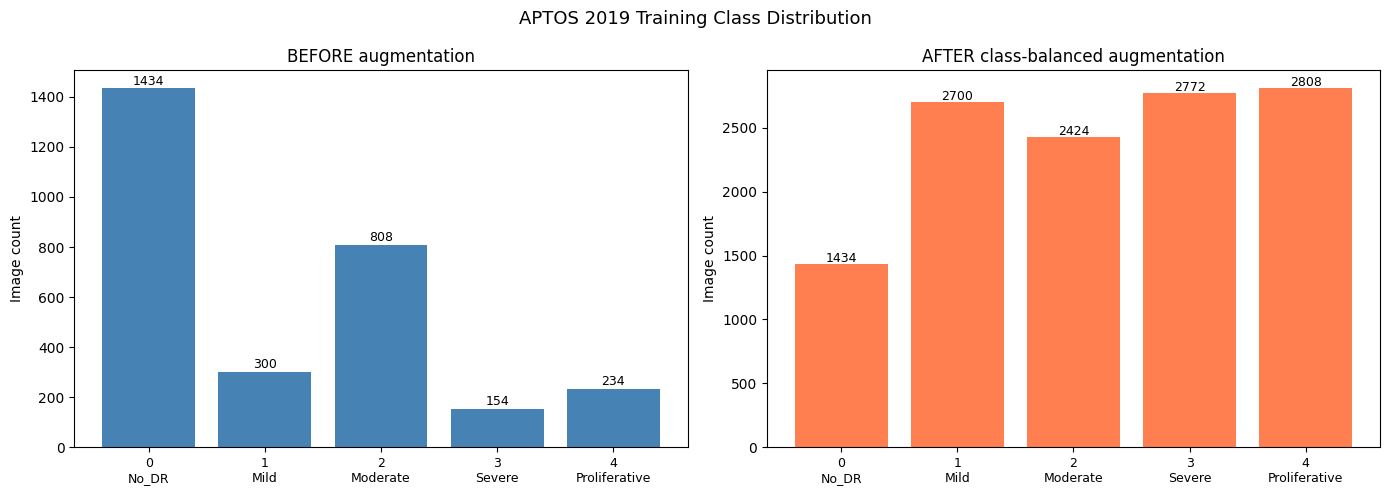


Chart saved: /content/drive/MyDrive/DR_PROJECT/preprocessed/aptos_class_distribution.png
Preprocessing complete. Proceed to Notebook 3 — U-Net Training + HSA.


In [6]:
# ---- Summary table ----
print(f"{'Cls':<4} {'Name':<15} {'Train':>7} {'Val':>6}")
print('-' * 34)
for cls, name in CLASS_NAMES.items():
    td = os.path.join(APTOS_OUT, 'train', str(cls))
    vd = os.path.join(APTOS_OUT, 'val',   str(cls))
    t  = len(os.listdir(td)) if os.path.exists(td) else 0
    v  = len(os.listdir(vd)) if os.path.exists(vd) else 0
    print(f'{cls:<4} {name:<15} {t:>7} {v:>6}')

# ---- Before / After bar charts ----
orig_counts = [int((train_df['diagnosis'] == c).sum()) for c in range(5)]
aug_counts  = [
    len(os.listdir(os.path.join(APTOS_OUT, 'train', str(c))))
    if os.path.exists(os.path.join(APTOS_OUT, 'train', str(c))) else 0
    for c in range(5)
]
xlabels = [f'{c}\n{CLASS_NAMES[c]}' for c in range(5)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

b1 = ax1.bar(range(5), orig_counts, color='steelblue')
ax1.set_title('BEFORE augmentation', fontsize=12)
ax1.set_xticks(range(5))
ax1.set_xticklabels(xlabels, fontsize=9)
ax1.set_ylabel('Image count')
for bar, v in zip(b1, orig_counts):
    ax1.text(bar.get_x() + bar.get_width() / 2, v + 15, str(v), ha='center', fontsize=9)

b2 = ax2.bar(range(5), aug_counts, color='coral')
ax2.set_title('AFTER class-balanced augmentation', fontsize=12)
ax2.set_xticks(range(5))
ax2.set_xticklabels(xlabels, fontsize=9)
ax2.set_ylabel('Image count')
for bar, v in zip(b2, aug_counts):
    ax2.text(bar.get_x() + bar.get_width() / 2, v + 15, str(v), ha='center', fontsize=9)

plt.suptitle('APTOS 2019 Training Class Distribution', fontsize=13)
plt.tight_layout()
save_path = os.path.join(OUTPUT_BASE, 'aptos_class_distribution.png')
plt.savefig(save_path, dpi=100, bbox_inches='tight')
plt.show()
print(f'\nChart saved: {save_path}')
print('Preprocessing complete. Proceed to Notebook 3 — U-Net Training + HSA.')